In [49]:
#TASK 1: Data Collection & Understanding


In [48]:
import pandas as pd

data = pd.read_csv("retail_sales.csv", sep=';', encoding='latin1')
data.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Day,Day_Sort,Month,Month_sort,Age_Group,Quantity_Category,Weekday_flag
0,1,2023/11/24,CUST001,Male,34,Beauty,3,50,150,Friday,5,November,11,2534,Few Items,Weekday
1,2,2023/02/27,CUST002,Female,26,Clothing,2,500,1000,Monday,1,February,2,2534,Few Items,Weekday
2,3,2023/01/13,CUST003,Male,50,Electronics,1,30,30,Friday,5,January,1,4554,Single Item,Weekday
3,4,2023/05/21,CUST004,Male,37,Clothing,1,500,500,Sunday,7,May,5,3544,Single Item,Weekend
4,5,2023/05/06,CUST005,Male,30,Beauty,2,50,100,Saturday,6,May,5,2534,Few Items,Weekend


In [28]:
# Structure
print("Shape:", data.shape)
print("Columns:", data.columns)
data.info()

Shape: (1000, 16)
Columns: Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Day',
       'Day_Sort', 'Month', 'Month_sort', 'Age_Group', 'Quantity_Category',
       'Weekday_flag'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Transaction ID     1000 non-null   int64 
 1   Date               1000 non-null   object
 2   Customer ID        1000 non-null   object
 3   Gender             1000 non-null   object
 4   Age                1000 non-null   int64 
 5   Product Category   1000 non-null   object
 6   Quantity           1000 non-null   int64 
 7   Price per Unit     1000 non-null   int64 
 8   Total Amount       1000 non-null   int64 
 9   Day                1000 non-null   object
 10  Day_Sort           1000 non-nul

In [51]:
#TASK 2: Data Cleaning & Feature Engineering

In [50]:
# Remove extra spaces and standardize column names
data.columns = data.columns.str.strip().str.replace(" ", "_")

print(data.columns)

Index(['Transaction_ID', 'Date', 'Customer_ID', 'Gender', 'Age',
       'Product_Category', 'Quantity', 'Price_per_Unit', 'Total_Amount', 'Day',
       'Day_Sort', 'Month', 'Month_sort', 'Age_Group', 'Quantity_Category',
       'Weekday_flag'],
      dtype='object')


In [30]:
data.isnull().sum()

Transaction_ID       0
Date                 0
Customer_ID          0
Gender               0
Age                  0
Product_Category     0
Quantity             0
Price_per_Unit       0
Total_Amount         0
Day                  0
Day_Sort             0
Month                0
Month_sort           0
Age_Group            0
Quantity_Category    0
Weekday_flag         0
dtype: int64

In [31]:
# Fill missing values using forward fill (latest method)
data.ffill(inplace=True)

In [32]:
data.drop_duplicates(inplace=True)

In [33]:
# Convert only if column exists (avoid errors)
if 'Age' in data.columns:
    data['Age'] = data['Age'].astype(int)

if 'Quantity' in data.columns:
    data['Quantity'] = data['Quantity'].astype(int)

In [34]:
# Create Total_Sales column safely
if 'Quantity' in data.columns and 'Price_per_Unit' in data.columns:
    data['Total_Sales'] = data['Quantity'] * data['Price_per_Unit']

In [52]:
#TASK 3: Exploratory Data Analysis (EDA)

In [35]:
data.describe()

,Transaction_ID,Age,Quantity,Price_per_Unit,Total_Amount,Day_Sort,Month_sort,Total_Sales
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000,3.95800,6.549000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632,2.02097,3.452755,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000,1.00000,1.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000,2.00000,4.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000,4.00000,6.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000,6.00000,10.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000,7.00000,12.000000,2000.000000


In [36]:
if 'Product_Category' in data.columns:
    category_sales = data.groupby('Product_Category')['Total_Sales'].sum()
    print(category_sales.sort_values(ascending=False))

Product_Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total_Sales, dtype: int64


In [37]:
if 'Gender' in data.columns:
    gender_sales = data.groupby('Gender')['Total_Sales'].sum()
    print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total_Sales, dtype: int64


In [38]:
if 'Customer_ID' in data.columns:
    top_customers = data.groupby('Customer_ID')['Total_Sales'].sum().sort_values(ascending=False).head(5)
    print(top_customers)

Customer_ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
Name: Total_Sales, dtype: int64


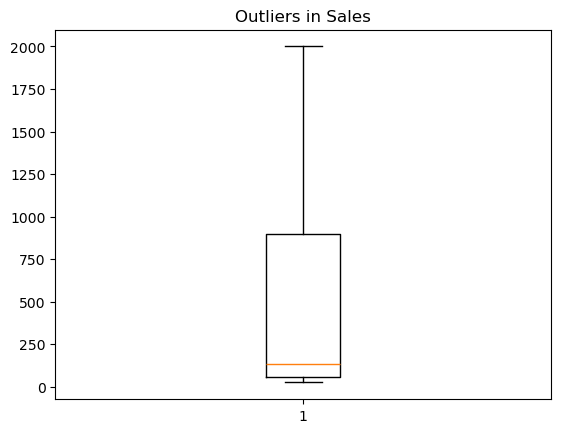

In [40]:
import matplotlib.pyplot as plt

plt.boxplot(data['Total_Amount'])
plt.title("Outliers in Sales")
plt.show()

In [ ]:
#TASK 4: Data Visualization

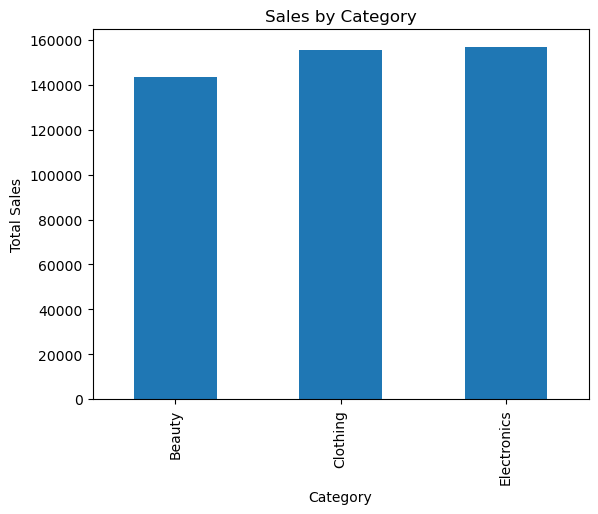

In [41]:
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

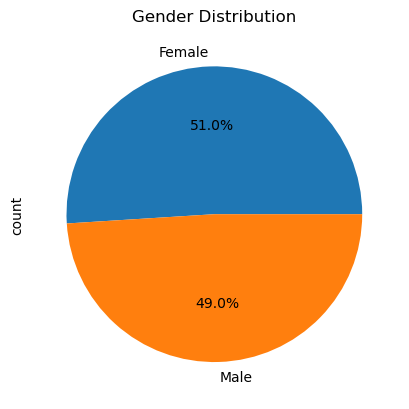

In [42]:
data['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

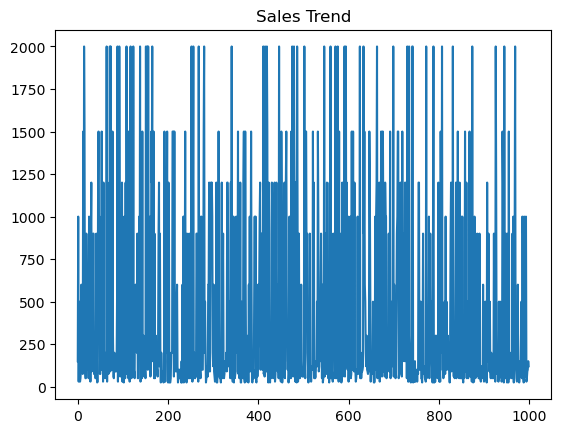

In [43]:
data['Total_Sales'].plot()
plt.title("Sales Trend")
plt.show()

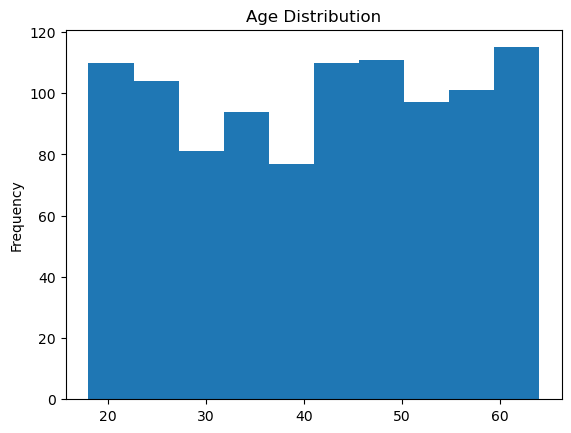

In [44]:
data['Age'].plot(kind='hist', bins=10)
plt.title("Age Distribution")
plt.show()

In [ ]:
#TASK 5: Predictive Modeling 

In [45]:
# Only select existing columns
features = []

if 'Age' in data.columns:
    features.append('Age')

if 'Quantity' in data.columns:
    features.append('Quantity')

X = data[features]
y = data['Total_Sales']

In [46]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [47]:
# Example prediction (adjust based on features)
model.predict([[30, 2]])

D:\All Apps Download\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([385.46894894])